# Omega60 laser sampling

In [10]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import math

from helpers import geometry, rwbeams, sampler, rwhist, collision


# INPUT

In [11]:
N_total=10000 #Number of impact (rays) that you want to simulate

## Support functions

### Sample of random laser points in a 2D window distribution normale

### Use of normal distribution in the sample of points 

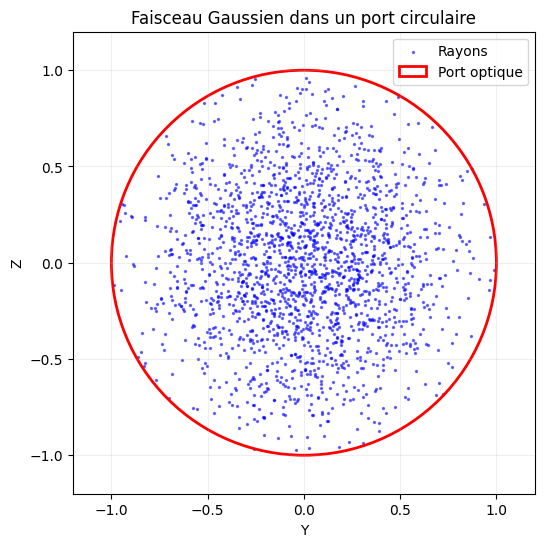

In [12]:


# --- Paramètres ---
radius = 1.0
c = np.array([0., 0., 0.]) # Centre
# t1 et t2 définissent le plan du cercle (ici YZ)
t1, t2 = np.array([0, 1, 0]), np.array([0, 0, 1])

# Distribution Gaussienne (concentrée au centre)
dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.4).rvs(size=(n, 2))

# --- Génération ---
# On utilise l1=2*radius et l2=2*radius car ta fonction utilise l1/2 comme rayon
xs = sampler.sample_window(
    t1, 
    t2, 
    l1=2*radius, 
    l2=2*radius, 
    center=c, 
    num_points=2000, 
    dist=dist_gauss
)

# --- Tracé ---
fig, ax = plt.subplots(figsize=(6,6))

# Tracé des points (Axe Y et Axe Z)
ax.scatter(xs[:,1], xs[:,2], s=2, alpha=0.5, color='blue', label="Rayons")

# Tracé du cercle de limite (radius=1.0)
circle = plt.Circle((c[1], c[2]), radius, color='red', fill=False, lw=2, label="Port optique")
ax.add_patch(circle)

# Esthétique
ax.set_aspect('equal')
ax.set_xlim(-radius*1.2, radius*1.2)
ax.set_ylim(-radius*1.2, radius*1.2)
ax.set_title("Faisceau Gaussien dans un port circulaire")
ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()

### Sample of random laser points in a 2D window distribution normale

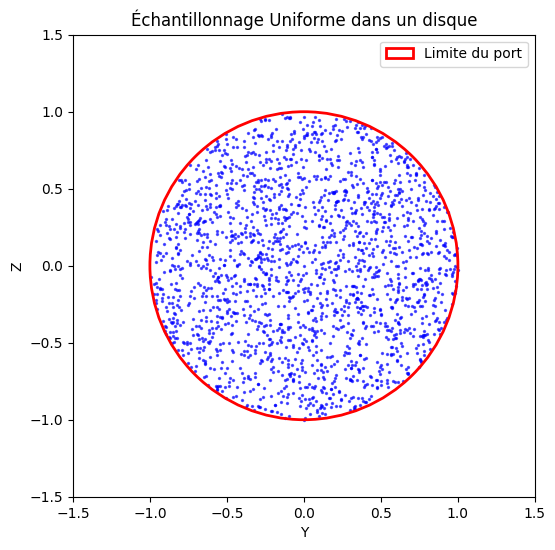

In [13]:
# 1. Définition de la distribution (Uniforme dans le carré [-1, 1])
dist_unif = lambda num_points: sp.stats.uniform.rvs(loc=-1.0, scale=2.0, size=(num_points, 2))

t1 = np.array([0., 1., 0.]) # axe Y
t2 = np.array([0., 0., 1.]) # axe Z
radius = 1.0

# 2. Appel corrigé avec les noms d'arguments
# On utilise l1 et l2 comme diamètres (2 * radius)
xs = sampler.sample_window(
    t1, 
    t2, 
    l1=2*radius, 
    l2=2*radius, 
    center=np.array([0., 0., 0.]), 
    num_points=2000, 
    dist=dist_unif
)

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(xs[:,1], xs[:,2], s=2, alpha=0.6, color='blue')

# Dessin du cercle limite (rayon = 1.0)
circle = plt.Circle((0, 0), radius, color='r', fill=False, linewidth=2, label="Limite du port")
ax.add_patch(circle)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# J'ai corrigé le titre car ici c'est une loi Uniforme (Flat-top)
ax.set_title("Échantillonnage Uniforme dans un disque")
ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.legend()
plt.show()


## Chamber and target geometry parameters

In [14]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [15]:
# =====================================================
# Chargement de la configuration Master
# =====================================================

# On utilise le module beams pour lire et VALIDER le fichier excel
# que tu as créé dans ton notebook "parameters"
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")


df_omega.head()

,id,LAT_rad,LONG_rad,energy,wavelength,l1,l2,xc,yc,zc,...,t1x,t1y,t1z,t2x,t2y,t2z,R,fx,fy,fz
0,OMEGA_J01,0.203169,1.570796,500,3.510000e-07,0.28,0.28,2.038592e-17,0.332927,1.616063,...,-1.000000,6.123234e-17,0,-5.997292e-17,-0.979432,0.201774,0.14,-6.818032e-20,-0.001113,-0.005405
1,OMEGA_J02,0.203169,4.712389,500,3.510000e-07,0.28,0.28,-6.115775e-17,-0.332927,1.616063,...,1.000000,-1.836970e-16,0,1.799188e-16,0.979432,0.201774,0.14,2.045410e-19,0.001113,-0.005405
2,OMEGA_J03,0.545768,0.890581,500,3.510000e-07,0.28,0.28,5.386876e-01,0.665855,1.410303,...,-0.777438,6.289602e-01,0,-5.375904e-01,-0.664498,0.519075,0.14,-1.801631e-03,-0.002227,-0.004717
3,OMEGA_J04,0.545768,2.251011,500,3.510000e-07,0.28,0.28,-5.386876e-01,0.665855,1.410303,...,-0.777438,-6.289602e-01,0,5.375904e-01,-0.664498,0.519075,0.14,1.801631e-03,-0.002227,-0.004717
4,OMEGA_J05,0.545768,4.032174,500,3.510000e-07,0.28,0.28,-5.386876e-01,-0.665855,1.410303,...,0.777438,-6.289602e-01,0,5.375904e-01,0.664498,0.519075,0.14,1.801631e-03,0.002227,-0.004717


## Impacts of the laser beams from window to a target sphere

## Simulation of impacts for 1 beam

### Simulation parameters

In [16]:
# 1. Prepare the row to match the format expected by beam_hit
row = df_omega.iloc[0]


# 2. Now launch the function with this "prepared" row
impacts_1window = collision.beam_hit(
    row, 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Effective impacts: {len(impacts_1window)} out of 10000 launched rays.")

Effective impacts: 10000 out of 10000 launched rays.


### Impacts data

In [17]:
impacts_1window.head()

,id,cs,l,xx,xy,xz,ux,uy,uz,xsphx,xsphy,xsphz,nx,ny,nz,r,long_rad,lat_rad,R
0,OMEGA_J01,-0.992041,1.649441,-0.016693,0.366128,1.609223,0.010081,-0.221771,-0.975047,-0.000066,0.000330,0.000942,-0.065615,0.330039,0.941684,0.001,1.767048,0.343195,0.14
1,OMEGA_J01,-0.992430,1.649419,0.031759,0.351236,1.612291,-0.019179,-0.212781,-0.976912,0.000125,0.000272,0.000954,0.124846,0.271618,0.954273,0.001,1.139957,0.303578,0.14
2,OMEGA_J01,-0.994881,1.649284,-0.027407,0.345629,1.613446,0.016552,-0.209411,-0.977688,-0.000108,0.000250,0.000962,-0.107794,0.250290,0.962151,0.001,1.977465,0.276006,0.14
3,OMEGA_J01,-0.985025,1.649826,-0.009455,0.283095,1.626329,0.005708,-0.171590,-0.985152,-0.000037,0.000002,0.000999,-0.037107,0.001989,0.999309,0.001,3.088047,0.037169,0.14
4,OMEGA_J01,-0.994304,1.649316,-0.028649,0.319010,1.618930,0.017302,-0.193331,-0.980981,-0.000113,0.000145,0.000983,-0.112665,0.145440,0.982931,0.001,2.229888,0.185027,0.14


### Representation of the impact of one beam

### 

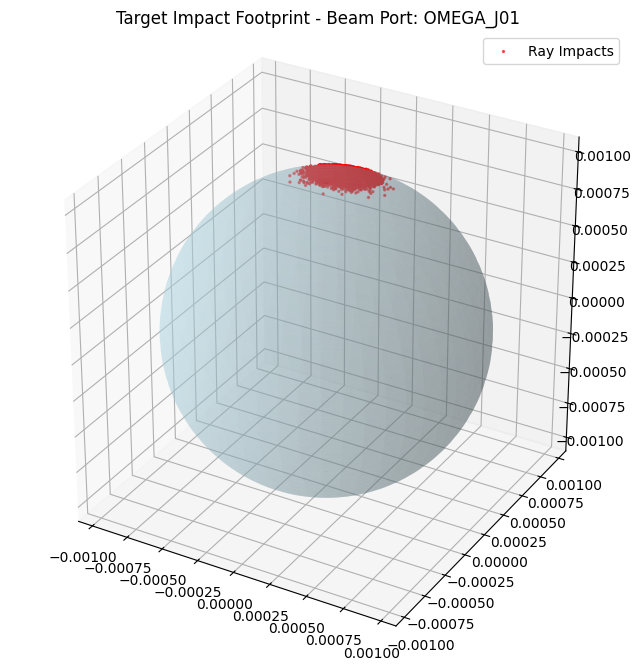

In [18]:
# 3. Maintenant tu peux appeler ta fonction de plot sans erreur
collision.plot_impact_footprint(impacts_1window, TARGET_RADIUS)